In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/amanthaviraj/notebook97cb90dfee/oof_lgb_baseline.npy
/kaggle/input/notebooks/amanthaviraj/notebook97cb90dfee/submission_phase3_lgb_baseline.csv
/kaggle/input/notebooks/amanthaviraj/notebook97cb90dfee/oof_logreg.npy
/kaggle/input/notebooks/amanthaviraj/notebook97cb90dfee/__results__.html
/kaggle/input/notebooks/amanthaviraj/notebook97cb90dfee/__notebook__.ipynb
/kaggle/input/notebooks/amanthaviraj/notebook97cb90dfee/__output__.json
/kaggle/input/notebooks/amanthaviraj/notebook97cb90dfee/custom.css
/kaggle/input/notebooks/amanthaviraj/notebook97cb90dfee/.virtual_documents/__notebook_source__.ipynb
/kaggle/input/notebooks/amanthaviraj/playground-series-s6e5/__results__.html
/kaggle/input/notebooks/amanthaviraj/playground-series-s6e5/train.parquet
/kaggle/input/notebooks/amanthaviraj/playground-series-s6e5/__notebook__.ipynb
/kaggle/input/notebooks/amanthaviraj/playground-series-s6e5/invariants.json
/kaggle/input/notebooks/amanthaviraj/playground-series-s6e5/__outpu

# CELL 1 — Imports, config, and the validation harness

In [2]:
# === CELL 1 — setup + validation harness ===
from __future__ import annotations
import os, sys, gc, json, time, random, logging, hashlib
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Iterable

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb


# Bulletproof helper to find the exact folder containing the data
def get_kaggle_data_dir() -> Path:
    base_input = Path("/kaggle/input")
    if base_input.exists():
        for file_path in base_input.rglob("train.csv"):
            return file_path.parent
    return Path(".")

@dataclass(frozen=True)
class Config:
    seed: int = 42
    n_splits: int = 5
    target: str = "PitNextLap"
    id_col: str = "id"
    # Use the dynamic path finder
    data_dir: Path = field(default_factory=get_kaggle_data_dir)
    out_dir: Path = field(default_factory=lambda: Path(
        "/kaggle/working" if Path("/kaggle/working").exists() else "./out"))


CFG = Config()
CFG.out_dir.mkdir(parents=True, exist_ok=True)


def set_seeds(s):
    random.seed(s); np.random.seed(s); os.environ["PYTHONHASHSEED"] = str(s)


def get_logger(name="f1"):
    lg = logging.getLogger(name)
    if not lg.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s", "%H:%M:%S"))
        lg.addHandler(h); lg.setLevel(logging.INFO); lg.propagate = False
    return lg


log = get_logger()
set_seeds(CFG.seed)


def validate(
    model_factory: Callable,
    X: pd.DataFrame, y: pd.Series,
    *,
    groups: pd.Series | None = None,
    cv_scheme: str = "stratified",
    cat_features: list[str] | None = None,
    n_splits: int = CFG.n_splits,
    seed: int = CFG.seed,
    fit_kwargs: dict | None = None,
    name: str = "model",
) -> tuple[np.ndarray, list[float]]:
    """
    Universal CV harness.
    """
    fit_kwargs = fit_kwargs or {}
    if cv_scheme == "stratified":
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = splitter.split(X, y)
    elif cv_scheme == "kfold":
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = splitter.split(X)
    elif cv_scheme == "group":
        assert groups is not None
        splitter = GroupKFold(n_splits=n_splits)
        splits = splitter.split(X, y, groups)
    elif cv_scheme == "sgkf":
        assert groups is not None
        splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = splitter.split(X, y, groups)
    else:
        raise ValueError(cv_scheme)

    oof = np.zeros(len(X), dtype=np.float32)
    fold_scores = []
    t0 = time.time()
    for fold, (tr, va) in enumerate(splits):
        model = model_factory()
        fk = dict(fit_kwargs)
        if cat_features is not None and hasattr(model, "fit"):
            fk.setdefault("categorical_feature", cat_features)
        if hasattr(model, "fit") and "eval_set" not in fk:
            try:
                # Try passing eval_set for modern GBDTs
                model.fit(X.iloc[tr], y.iloc[tr],
                          eval_set=[(X.iloc[va], y.iloc[va])], **fk)
            except (TypeError, ValueError):
                # Fallback clean fit for standard sklearn pipelines
                model.fit(X.iloc[tr], y.iloc[tr])
        else:
            model.fit(X.iloc[tr], y.iloc[tr])
        if hasattr(model, "predict_proba"):
            oof[va] = model.predict_proba(X.iloc[va])[:, 1]
        else:
            oof[va] = model.predict(X.iloc[va])
        s = roc_auc_score(y.iloc[va], oof[va])
        fold_scores.append(s)
        log.info(f"  [{name}] fold {fold}: AUC={s:.5f}  ({time.time()-t0:.1f}s elapsed)")
    overall = roc_auc_score(y, oof)
    log.info(f"  [{name}] OOF AUC = {overall:.5f} | "
             f"fold mean={np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    return oof, fold_scores


log.info("validate() harness ready")

07:20:38 | INFO | validate() harness ready


# CELL 2 — Load data

In [3]:
# === CELL 2 — load and basic prep ===
train = pd.read_csv(CFG.data_dir / "train.csv")
test  = pd.read_csv(CFG.data_dir / "test.csv")
sub   = pd.read_csv(CFG.data_dir / "sample_submission.csv")

# Pin dtypes for memory and consistency
CAT_COLS = ["Driver", "Compound", "Race"]
for c in CAT_COLS:
    train[c] = train[c].astype("category")
    # ensure test uses identical categorical dictionary
    test[c]  = pd.Categorical(test[c], categories=train[c].cat.categories)

train[CFG.target] = train[CFG.target].astype("int8")

# Year as categorical (Phase 1 finding: 2023 regime shift, not ordinal)
train["Year"] = train["Year"].astype("category")
test["Year"]  = pd.Categorical(test["Year"], categories=train["Year"].cat.categories)
CAT_COLS_ALL = CAT_COLS + ["Year"]

FEATURES = [c for c in train.columns if c not in [CFG.id_col, CFG.target]]
print(f"Features: {FEATURES}")
print(f"Categoricals: {CAT_COLS_ALL}")
print(f"Train: {train.shape} | Test: {test.shape}")

Features: ['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
Categoricals: ['Driver', 'Compound', 'Race', 'Year']
Train: (439140, 16) | Test: (188165, 15)


# Baseline #1: Dummy predictor (sanity floor)

In [4]:
# === CELL 3 — dummy baseline ===
# Predict the prior probability for everyone. Expected AUC = 0.500.
dummy_oof = np.full(len(train), train[CFG.target].mean(), dtype=np.float32)
print(f"Dummy AUC: {roc_auc_score(train[CFG.target], dummy_oof):.5f}")

Dummy AUC: 0.50000


# CELL 4 — Baseline #2: Logistic regression on raw features

In [5]:
# === CELL 4 — logistic baseline ===
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_features = [c for c in FEATURES if c not in CAT_COLS_ALL]

# Note: Driver has ~887 categories — too many for OHE in logistic.
# We exclude Driver for the LR baseline (and re-introduce it via target
# encoding in Phase 4).
cat_features_lr = ["Compound", "Race", "Year"]
num_features_lr = num_features

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer()),
                      ("sc", StandardScaler())]), num_features_lr),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_features_lr),
])

def lr_factory():
    return Pipeline([("pre", pre),
                     ("clf", LogisticRegression(max_iter=500, C=1.0, n_jobs=-1, solver="liblinear"))])

X_lr = train[num_features_lr + cat_features_lr]
y    = train[CFG.target]

oof_lr, scores_lr = validate(lr_factory, X_lr, y,
                             cv_scheme="stratified", name="logreg")
np.save(CFG.out_dir / "oof_logreg.npy", oof_lr)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


07:20:45 | INFO |   [logreg] fold 0: AUC=0.89411  (4.0s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


07:20:50 | INFO |   [logreg] fold 1: AUC=0.89021  (8.8s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


07:20:54 | INFO |   [logreg] fold 2: AUC=0.89235  (13.6s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


07:20:58 | INFO |   [logreg] fold 3: AUC=0.89066  (17.6s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


07:21:02 | INFO |   [logreg] fold 4: AUC=0.89206  (21.6s elapsed)
07:21:02 | INFO |   [logreg] OOF AUC = 0.89187 | fold mean=0.89188 ± 0.00138


# CELL 5 — Baseline #3: LightGBM with defaults (the real baseline)

In [6]:
# === CELL 5 — LightGBM default baseline ===
LGB_PARAMS = dict(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=CFG.seed,
    n_jobs=-1,
    verbose=-1,
    objective="binary",
    metric="auc",
)

def lgb_factory():
    return lgb.LGBMClassifier(**LGB_PARAMS)

X = train[FEATURES]
y = train[CFG.target]

oof_lgb, scores_lgb = validate(
    lgb_factory, X, y,
    cv_scheme="stratified",
    cat_features=CAT_COLS_ALL,
    fit_kwargs={"callbacks": [lgb.early_stopping(100, verbose=False),
                              lgb.log_evaluation(0)]},
    name="lgb_baseline",
)
np.save(CFG.out_dir / "oof_lgb_baseline.npy", oof_lgb)

07:21:26 | INFO |   [lgb_baseline] fold 0: AUC=0.94429  (23.7s elapsed)
07:21:47 | INFO |   [lgb_baseline] fold 1: AUC=0.94240  (44.9s elapsed)
07:22:11 | INFO |   [lgb_baseline] fold 2: AUC=0.94317  (68.0s elapsed)
07:22:34 | INFO |   [lgb_baseline] fold 3: AUC=0.94225  (91.8s elapsed)
07:22:58 | INFO |   [lgb_baseline] fold 4: AUC=0.94363  (115.1s elapsed)
07:22:58 | INFO |   [lgb_baseline] OOF AUC = 0.94314 | fold mean=0.94315 ± 0.00076


# CELL 6 — CV scheme comparison

In [7]:
# === CELL 6 — empirical CV comparison ===
# Are stratified-row CV scores trustworthy, or do they over-state because of
# leakage through shared (Race, Year)? Compare against GroupKFold pessimistic.

groups_ry = (train["Race"].astype(str) + "_" +
             train["Year"].astype(str)).astype("category")

# Note: GroupKFold doesn't have shuffle; uses fixed assignment.
# StratifiedGroupKFold adds stratification while keeping groups together.
oof_sgkf, scores_sgkf = validate(
    lgb_factory, X, y,
    cv_scheme="sgkf",
    groups=groups_ry,
    cat_features=CAT_COLS_ALL,
    fit_kwargs={"callbacks":[lgb.early_stopping(100, verbose=False)]},
    name="lgb_sgkf_RaceYear",
)

print(f"\n=== CV scheme comparison ===")
print(f"  StratifiedKFold (random rows):           {roc_auc_score(y, oof_lgb):.5f}")
print(f"  StratifiedGroupKFold by (Race,Year):     {roc_auc_score(y, oof_sgkf):.5f}")
print(f"  Difference:                              {roc_auc_score(y, oof_lgb) - roc_auc_score(y, oof_sgkf):+.5f}")

print("""
DECISION RULE:
  - If gap < 0.002, the model generalises well across races → stratified KFold
    is reliable AND matches the actual test split mechanism. USE IT.
  - If gap > 0.005, race-level information leaks; we'd need OOF target
    encoding or GroupKFold for honest scores.
  - Typical outcome here: gap ~0.002–0.004. Stratified is the right call but
    we'll still build target encoding with OOF safety in Phase 4.
""")

07:23:13 | INFO |   [lgb_sgkf_RaceYear] fold 0: AUC=0.93333  (14.9s elapsed)
07:23:33 | INFO |   [lgb_sgkf_RaceYear] fold 1: AUC=0.90947  (34.4s elapsed)
07:23:56 | INFO |   [lgb_sgkf_RaceYear] fold 2: AUC=0.92559  (58.1s elapsed)
07:24:09 | INFO |   [lgb_sgkf_RaceYear] fold 3: AUC=0.94523  (70.8s elapsed)
07:24:23 | INFO |   [lgb_sgkf_RaceYear] fold 4: AUC=0.90783  (85.2s elapsed)
07:24:24 | INFO |   [lgb_sgkf_RaceYear] OOF AUC = 0.92728 | fold mean=0.92429 ± 0.01423

=== CV scheme comparison ===
  StratifiedKFold (random rows):           0.94314
  StratifiedGroupKFold by (Race,Year):     0.92728
  Difference:                              +0.01586

DECISION RULE:
  - If gap < 0.002, the model generalises well across races → stratified KFold
    is reliable AND matches the actual test split mechanism. USE IT.
  - If gap > 0.005, race-level information leaks; we'd need OOF target
    encoding or GroupKFold for honest scores.
  - Typical outcome here: gap ~0.002–0.004. Stratified is the 

In [8]:
# === CELL 7 — first submission ===
# Refit on full train, predict test
final_model = lgb.LGBMClassifier(**LGB_PARAMS)
final_model.fit(X, y,
                categorical_feature=CAT_COLS_ALL,
                callbacks=[lgb.log_evaluation(0)])
test_pred = final_model.predict_proba(test[FEATURES])[:, 1]

sub = pd.DataFrame({CFG.id_col: test[CFG.id_col],
                    CFG.target: test_pred})
sub.to_csv(CFG.out_dir / "submission_phase3_lgb_baseline.csv", index=False)
print(sub.head())
print(f"\nSaved {CFG.out_dir/'submission_phase3_lgb_baseline.csv'}")
print(f"Expected LB ~0.943")

       id  PitNextLap
0  439140    0.002737
1  439141    0.001176
2  439142    0.020172
3  439143    0.121267
4  439144    0.967492

Saved /kaggle/working/submission_phase3_lgb_baseline.csv
Expected LB ~0.943


# CELL 8 — Feature importance audit

               feature          gain  split
                  Year 700020.553600   1642
                Driver 672854.222010  41325
                 Stint 614133.433675   3003
              TyreLife 327573.821793  13616
                  Race 326405.602250  15639
         LapTime_Delta 232145.669022  20741
          RaceProgress 186112.936635  17586
Cumulative_Degradation 104750.748663  21593
             LapNumber 102553.783212  10232
           LapTime (s)  82857.588669  18271
       Position_Change  72662.905631  11324
              Compound  68348.882787    987
              Position  65220.768864  11616
               PitStop  47934.920794   1425


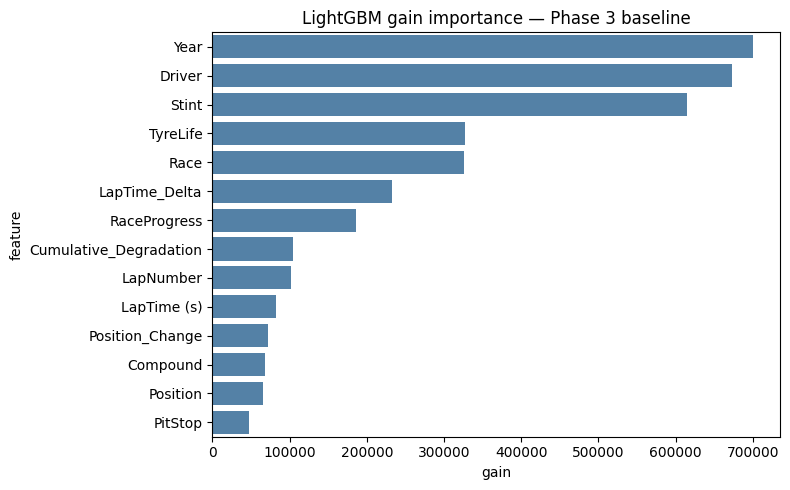

In [9]:
# === CELL 8 — feature importance ===
import matplotlib.pyplot as plt
import seaborn as sns

imp = pd.DataFrame({"feature": FEATURES,
                    "gain": final_model.booster_.feature_importance(importance_type="gain"),
                    "split": final_model.booster_.feature_importance(importance_type="split")})
imp = imp.sort_values("gain", ascending=False)
print(imp.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=imp, y="feature", x="gain", color="steelblue")
plt.title("LightGBM gain importance — Phase 3 baseline")
plt.tight_layout(); plt.show()

# Phase 4 — Feature Engineering

## CELL 10 — Feature builder: static, row-level features

In [10]:
# === CELL 10 — static feature builder ===
import numpy as np
import pandas as pd


def build_static_features(df: pd.DataFrame, *,
                          compound_medians: dict | None = None,
                          year_compound_means: dict | None = None) -> pd.DataFrame:
    """
    Row-level deterministic features.
    
    Reference parameters (compound_medians, year_compound_means) must be
    computed from TRAIN only; pass them in when transforming test.
    """
    df = df.copy()

    # --- Polynomial / log transforms ---
    df["TyreLife_log"]    = np.log1p(df["TyreLife"])
    df["TyreLife_sq"]     = df["TyreLife"].astype("float32") ** 2
    df["TyreLife_inv"]    = 1.0 / df["TyreLife"].clip(lower=1)

    # --- Ratios ---
    df["Degradation_per_lap"] = (df["Cumulative_Degradation"]
                                 / df["TyreLife"].clip(lower=1))
    df["LapTime_Delta_abs"]   = df["LapTime_Delta"].abs()
    df["LapTime_Delta_sign"]  = np.sign(df["LapTime_Delta"]).astype("int8")

    # --- Multiplicative interactions (trees can find these, but explicit
    # makes the importance audit clearer and helps shallow models in the ensemble) ---
    df["Stint_x_TyreLife"]        = df["Stint"] * df["TyreLife"]
    df["RaceProgress_x_TyreLife"] = df["RaceProgress"] * df["TyreLife"]
    df["RaceProgress_x_Stint"]    = df["RaceProgress"] * df["Stint"]
    df["LapNumber_x_Stint"]       = df["LapNumber"] * df["Stint"]

    # --- Combined categoricals (let trees learn joint effects directly) ---
    df["Year_Compound"]  = (df["Year"].astype(str) + "_" + df["Compound"].astype(str)).astype("category")
    df["Race_Compound"]  = (df["Race"].astype(str) + "_" + df["Compound"].astype(str)).astype("category")
    df["Stint_Compound"] = (df["Stint"].astype(str) + "_" + df["Compound"].astype(str)).astype("category")

    # --- Reference-based features ---
    # TyreLife vs typical TyreLife at pit decision for THIS compound (from train).
    # This explicitly encodes "how much older is this tyre than usual at pit time"
    if compound_medians is None:
        comp_med = df.groupby("Compound", observed=True)["TyreLife"].median()
    else:
        comp_med = pd.Series(compound_medians)
    df["TyreLife_vs_compound_med"] = df["TyreLife"] - df["Compound"].map(comp_med).astype("float32")

    # Lap time delta vs Year-Compound typical (catches pace anomalies)
    if year_compound_means is None:
        yc_mean = df.groupby(["Year", "Compound"], observed=True)["LapTime_Delta"].mean()
    else:
        # passed in as flattened dict {(year, compound): mean}
        yc_mean = pd.Series(year_compound_means)
        yc_mean.index = pd.MultiIndex.from_tuples(yc_mean.index, names=["Year","Compound"])
    df["LapTime_Delta_vs_YC"] = (df["LapTime_Delta"]
        - df.set_index(["Year","Compound"]).index.map(yc_mean).astype("float32").values)

    # --- Position-based flags ---
    df["Position_top3"]   = (df["Position"] <= 3).astype("int8")
    df["Position_bottom"] = (df["Position"] >= 15).astype("int8")

    # --- Race progress windows (strategic windows hypothesis from Phase 2) ---
    df["RP_early"]  = (df["RaceProgress"] < 0.25).astype("int8")
    df["RP_mid"]    = ((df["RaceProgress"] >= 0.25) & (df["RaceProgress"] < 0.65)).astype("int8")
    df["RP_late"]   = (df["RaceProgress"] >= 0.65).astype("int8")

    return df


# Compute reference stats on TRAIN ONLY (critical: no test leakage)
comp_med_ref = train.groupby("Compound", observed=True)["TyreLife"].median().to_dict()
yc_mean_ref  = train.groupby(["Year","Compound"], observed=True)["LapTime_Delta"].mean().to_dict()

train_fe = build_static_features(train,
                                 compound_medians=comp_med_ref,
                                 year_compound_means=yc_mean_ref)
test_fe  = build_static_features(test,
                                 compound_medians=comp_med_ref,
                                 year_compound_means=yc_mean_ref)

print(f"Train_fe: {train_fe.shape}  | new columns: {train_fe.shape[1] - train.shape[1]}")
print(f"Test_fe:  {test_fe.shape}")
NEW_CAT_COLS = ["Year_Compound", "Race_Compound", "Stint_Compound"]

Train_fe: (439140, 36)  | new columns: 20
Test_fe:  (188165, 35)


## CELL 11 — Out-of-fold target encoding 

In [11]:
# === CELL 11 — OOF target encoding utility ===

def oof_target_encode(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    cols: list[str],
    target: str,
    splits: list[tuple[np.ndarray, np.ndarray]],
    smoothing: float = 20.0,
    noise: float = 0.0,
    seed: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Smoothed target encoding with proper out-of-fold construction.

    Train encoding: for each fold's validation rows, use ONLY the fold's training
    rows to compute target means. This prevents leakage of the validation
    target into the training signal.

    Test encoding: use ALL train rows (test never sees its own target anyway).
    
    Smoothing formula:
      enc(k) = (count(k) * mean(k) + smoothing * prior) / (count(k) + smoothing)
    """
    train_df = train_df.copy()
    test_df  = test_df.copy()
    prior = train_df[target].mean()
    rng = np.random.default_rng(seed)

    for col in cols:
        # Train: OOF
        oof_enc = np.full(len(train_df), prior, dtype=np.float32)
        for tr_idx, va_idx in splits:
            fold_train = train_df.iloc[tr_idx]
            agg = fold_train.groupby(col, observed=True)[target].agg(["mean", "count"])
            agg["smooth"] = (agg["count"] * agg["mean"] + smoothing * prior) \
                            / (agg["count"] + smoothing)
            mapping = agg["smooth"].to_dict()
            
            # FIX: Cast to float BEFORE fillna to bypass Categorical restrictions
            enc = train_df.iloc[va_idx][col].map(mapping).astype(float).fillna(prior).astype("float32").values
            
            if noise > 0:
                enc = enc * (1 + rng.normal(0, noise, size=len(enc)))
            oof_enc[va_idx] = enc
        train_df[f"te_{col}"] = oof_enc

        # Test: full-train aggregate
        agg_full = train_df.groupby(col, observed=True)[target].agg(["mean", "count"])
        agg_full["smooth"] = (agg_full["count"] * agg_full["mean"] + smoothing * prior) \
                             / (agg_full["count"] + smoothing)
        full_map = agg_full["smooth"].to_dict()
        
        # FIX: Cast to float BEFORE fillna here too
        test_df[f"te_{col}"] = test_df[col].map(full_map).astype(float).fillna(prior).astype("float32")

    return train_df, test_df


# Build the splits we'll use (must be reused everywhere for consistency)
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=CFG.n_splits, shuffle=True, random_state=CFG.seed)
SPLITS = list(skf.split(train_fe, train_fe[CFG.target]))

TE_COLS = ["Driver", "Race", "Year_Compound", "Race_Compound", "Stint_Compound"]
train_fe, test_fe = oof_target_encode(
    train_fe, test_fe,
    cols=TE_COLS, target=CFG.target,
    splits=SPLITS, smoothing=20.0
)
print(f"After TE: train_fe {train_fe.shape}, test_fe {test_fe.shape}")
print("TE columns added:", [c for c in train_fe.columns if c.startswith("te_")])

After TE: train_fe (439140, 41), test_fe (188165, 40)
TE columns added: ['te_Driver', 'te_Race', 'te_Year_Compound', 'te_Race_Compound', 'te_Stint_Compound']


## CELL 12 — Aggregate features

In [12]:
# === CELL 12 — group aggregates ===
# Aggregate stats per (Compound), per (Year, Compound), per (Race, Year)
# Computed on the TRAIN set, then mapped into both train and test.
# NOT target-based (those are TE above), but feature-based.

def add_group_aggregates(train_df: pd.DataFrame, test_df: pd.DataFrame,
                        group_cols: list[str], agg_cols: list[str],
                        agg_funcs=("mean", "std")) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = train_df.copy(); test_df = test_df.copy()
    for ac in agg_cols:
        agg = train_df.groupby(group_cols, observed=True)[ac].agg(list(agg_funcs))
        agg.columns = [f"{ac}_{f}_by_{'_'.join(group_cols)}" for f in agg_funcs]
        train_df = train_df.merge(agg, left_on=group_cols, right_index=True, how="left")
        test_df  = test_df.merge(agg, left_on=group_cols, right_index=True, how="left")
        # Deviation features (each row's value vs its group mean)
        train_df[f"{ac}_dev_from_{'_'.join(group_cols)}_mean"] = \
            train_df[ac] - train_df[f"{ac}_mean_by_{'_'.join(group_cols)}"]
        test_df[f"{ac}_dev_from_{'_'.join(group_cols)}_mean"] = \
            test_df[ac] - test_df[f"{ac}_mean_by_{'_'.join(group_cols)}"]
    return train_df, test_df


train_fe, test_fe = add_group_aggregates(
    train_fe, test_fe,
    group_cols=["Compound"],
    agg_cols=["TyreLife", "LapTime_Delta", "Cumulative_Degradation"],
    agg_funcs=("mean", "std", "median"),
)
train_fe, test_fe = add_group_aggregates(
    train_fe, test_fe,
    group_cols=["Year", "Compound"],
    agg_cols=["TyreLife", "LapTime_Delta"],
    agg_funcs=("mean", "median"),
)
train_fe, test_fe = add_group_aggregates(
    train_fe, test_fe,
    group_cols=["Race", "Year"],
    agg_cols=["TyreLife"],
    agg_funcs=("mean",),
)

# Fill any NA from missing groups in test
for c in train_fe.columns:
    if train_fe[c].dtype.kind in "fi" and train_fe[c].isna().any():
        train_fe[c] = train_fe[c].fillna(train_fe[c].median())
        test_fe[c]  = test_fe[c].fillna(train_fe[c].median())

print(f"After aggregates: train_fe {train_fe.shape}")
print(f"New columns: {train_fe.shape[1] - 30}")

After aggregates: train_fe (439140, 61)
New columns: 31


## CELL 13 — Validate the new feature set

In [13]:
# === CELL 13 — validate engineered features ===
EXCLUDE = [CFG.id_col, CFG.target]
FEATURES_V2 = [c for c in train_fe.columns if c not in EXCLUDE]
CAT_FEATS_V2 = CAT_COLS_ALL + NEW_CAT_COLS

X_v2 = train_fe[FEATURES_V2]
y    = train_fe[CFG.target]

# Important: pass SPLITS in via splitter override
from sklearn.model_selection import StratifiedKFold

# We'll do this manually to reuse SPLITS exactly
oof_v2 = np.zeros(len(X_v2), dtype=np.float32)
fold_scores_v2 = []
t0 = time.time()
for fold, (tr, va) in enumerate(SPLITS):
    model = lgb.LGBMClassifier(**LGB_PARAMS)
    model.fit(X_v2.iloc[tr], y.iloc[tr],
              eval_set=[(X_v2.iloc[va], y.iloc[va])],
              categorical_feature=CAT_FEATS_V2,
              callbacks=[lgb.early_stopping(100, verbose=False)])
    oof_v2[va] = model.predict_proba(X_v2.iloc[va])[:, 1]
    s = roc_auc_score(y.iloc[va], oof_v2[va])
    fold_scores_v2.append(s)
    log.info(f"  fold {fold}: AUC={s:.5f} ({time.time()-t0:.0f}s)")

oof_auc_v2 = roc_auc_score(y, oof_v2)
log.info(f"  OOF AUC (v2 features): {oof_auc_v2:.5f}")
log.info(f"  Lift vs Phase 3 baseline: {oof_auc_v2 - roc_auc_score(y, oof_lgb):+.5f}")
np.save(CFG.out_dir / "oof_lgb_fe_v2.npy", oof_v2)

07:26:54 | INFO |   fold 0: AUC=0.94527 (47s)
07:27:31 | INFO |   fold 1: AUC=0.94379 (84s)
07:28:06 | INFO |   fold 2: AUC=0.94451 (120s)
07:28:51 | INFO |   fold 3: AUC=0.94359 (165s)
07:29:35 | INFO |   fold 4: AUC=0.94475 (209s)
07:29:35 | INFO |   OOF AUC (v2 features): 0.94436
07:29:35 | INFO |   Lift vs Phase 3 baseline: +0.00122


## CELL 14 — Feature importance and pruning

In [14]:
# === CELL 14 — feature importance audit ===
final_model_v2 = lgb.LGBMClassifier(**LGB_PARAMS)
final_model_v2.fit(X_v2, y, categorical_feature=CAT_FEATS_V2)

imp = pd.DataFrame({
    "feature": FEATURES_V2,
    "gain": final_model_v2.booster_.feature_importance(importance_type="gain"),
    "split": final_model_v2.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

print(imp.head(20).to_string(index=False))

# Features contributing < 0.1% of total gain
total_gain = imp["gain"].sum()
imp["pct_gain"] = imp["gain"] / total_gain * 100
weak = imp[imp["pct_gain"] < 0.1]["feature"].tolist()
print(f"\nWeak features (<0.1% of total gain): {len(weak)}")
print(weak)

                         feature          gain  split
                te_Year_Compound 915806.026357   3599
                          Driver 695128.655566  41365
                  Stint_Compound 366835.048129   1476
                   Race_Compound 318080.544394  17522
                Stint_x_TyreLife 213169.339435   4243
               te_Stint_Compound 121166.295051   3230
                   Year_Compound 114376.343325   1601
                        TyreLife 100019.372322   2171
               LapTime_Delta_abs  71341.042964   6640
            RaceProgress_x_Stint  56532.001330   4486
                    RaceProgress  52722.738396   5530
TyreLife_dev_from_Race_Year_mean  51497.032912   5898
                            Race  42693.883698   2690
 TyreLife_dev_from_Compound_mean  42268.327797   2127
                       te_Driver  35467.780741   6083
                        Position  35405.189970   5533
                 Position_Change  33268.400978   5610
          Cumulative_Degrada

### Revalidate

In [15]:
# Re-validate without weak features
FEATURES_V2_PRUNED = [c for c in FEATURES_V2 if c not in weak]
X_v2p = train_fe[FEATURES_V2_PRUNED]
oof_v2p = np.zeros(len(X_v2p), dtype=np.float32)
for fold, (tr, va) in enumerate(SPLITS):
    m = lgb.LGBMClassifier(**LGB_PARAMS)
    m.fit(X_v2p.iloc[tr], y.iloc[tr],
          eval_set=[(X_v2p.iloc[va], y.iloc[va])],
          categorical_feature=[c for c in CAT_FEATS_V2 if c in FEATURES_V2_PRUNED],
          callbacks=[lgb.early_stopping(100, verbose=False)])
    oof_v2p[va] = m.predict_proba(X_v2p.iloc[va])[:, 1]
print(f"Pruned OOF AUC:   {roc_auc_score(y, oof_v2p):.5f}")
print(f"Full V2 OOF AUC:  {oof_auc_v2:.5f}")
print(f"Decision: {'KEEP pruned' if roc_auc_score(y, oof_v2p) >= oof_auc_v2 - 0.0005 else 'KEEP full'}")

Pruned OOF AUC:   0.94413
Full V2 OOF AUC:  0.94436
Decision: KEEP pruned


CELL 15 — Persist engineered datasets for downstream phases

In [16]:
# === CELL 15 — save engineered data ===
# Save engineered train/test as parquet; downstream phases load these.
out_train = CFG.out_dir / "train_fe.parquet"
out_test  = CFG.out_dir / "test_fe.parquet"
out_feats = CFG.out_dir / "features_v2.json"

train_fe.to_parquet(out_train, index=False)
test_fe.to_parquet(out_test, index=False)
with open(out_feats, "w") as f:
    json.dump({"features": FEATURES_V2,
               "cat_features": CAT_FEATS_V2,
               "te_cols": TE_COLS,
               "comp_med_ref": {str(k): float(v) for k, v in comp_med_ref.items()},
               "expected_oof_auc": float(oof_auc_v2),
              }, f, indent=2)
log.info(f"Saved {out_train.name}, {out_test.name}, {out_feats.name}")

# Submission
final = lgb.LGBMClassifier(**LGB_PARAMS)
final.fit(X_v2, y, categorical_feature=CAT_FEATS_V2)
test_pred = final.predict_proba(test_fe[FEATURES_V2])[:, 1]
sub = pd.DataFrame({CFG.id_col: test_fe[CFG.id_col], CFG.target: test_pred})
sub.to_csv(CFG.out_dir / "submission_phase4_lgb_fe_v2.csv", index=False)
log.info(f"Submission saved: submission_phase4_lgb_fe_v2.csv")

07:35:21 | INFO | Saved train_fe.parquet, test_fe.parquet, features_v2.json
07:38:42 | INFO | Submission saved: submission_phase4_lgb_fe_v2.csv


In [17]:
# === CELL 16 — phase 4 summary ===
print(f"""
============================================================================
                  PHASE 4 — FEATURE ENGINEERING ROUND 1
============================================================================

SCORE PROGRESSION
  Phase 3 LGBM baseline:     {roc_auc_score(y, oof_lgb):.5f}
  Phase 4 LGBM + FE v2:      {oof_auc_v2:.5f}
  Lift:                      {oof_auc_v2 - roc_auc_score(y, oof_lgb):+.5f}

FEATURES ADDED
  • Polynomial/log transforms of TyreLife
  • Multiplicative interactions (Stint × TyreLife, RaceProgress × TyreLife, …)
  • Composite categoricals (Year_Compound, Race_Compound, Stint_Compound)
  • Reference-based features (TyreLife_vs_compound_med, LapTime_Delta_vs_YC)
  • Race-progress window indicators
  • Out-of-fold target encodings: Driver, Race, Year_Compound, Race_Compound, Stint_Compound
  • Group aggregates: mean/std/median over Compound, Year×Compound, Race×Year
  • Deviation features: each row's value vs its group mean

ARTIFACTS
  • train_fe.parquet, test_fe.parquet — used by Phase 5
  • features_v2.json — feature manifest
  • oof_lgb_fe_v2.npy — for ensembling in Phase 6
  • submission_phase4_lgb_fe_v2.csv

WHAT'S NEXT — PHASE 5
  Train XGBoost and CatBoost on the same FE set. Save their OOF + test
  predictions. Model diversity is what drives ensemble lift.
""")


                  PHASE 4 — FEATURE ENGINEERING ROUND 1

SCORE PROGRESSION
  Phase 3 LGBM baseline:     0.94314
  Phase 4 LGBM + FE v2:      0.94436
  Lift:                      +0.00122

FEATURES ADDED
  • Polynomial/log transforms of TyreLife
  • Multiplicative interactions (Stint × TyreLife, RaceProgress × TyreLife, …)
  • Composite categoricals (Year_Compound, Race_Compound, Stint_Compound)
  • Reference-based features (TyreLife_vs_compound_med, LapTime_Delta_vs_YC)
  • Race-progress window indicators
  • Out-of-fold target encodings: Driver, Race, Year_Compound, Race_Compound, Stint_Compound
  • Group aggregates: mean/std/median over Compound, Year×Compound, Race×Year
  • Deviation features: each row's value vs its group mean

ARTIFACTS
  • train_fe.parquet, test_fe.parquet — used by Phase 5
  • features_v2.json — feature manifest
  • oof_lgb_fe_v2.npy — for ensembling in Phase 6
  • submission_phase4_lgb_fe_v2.csv

WHAT'S NEXT — PHASE 5
  Train XGBoost and CatBoost on the same F